# **OpenF1**

## Import necessary packages

In [38]:
import pandas as pd
import numpy as np
import requests
from urllib.request import urlopen
import json
from matplotlib import pyplot as plt
import seaborn as sns
from pandasql import sqldf

## Sessions

In [3]:
COUNTRY = "Bahrain"

BASE_URL = f"https://api.openf1.org/v1/sessions?year=2026&country_name={COUNTRY}"

response = urlopen(BASE_URL)
data = json.loads(response.read().decode('utf-8'))
sessions = pd.DataFrame(data)
sessions

,session_key,session_type,session_name,date_start,date_end,meeting_key,circuit_key,circuit_short_name,country_key,country_code,country_name,location,gmt_offset,year
0,11465,Practice,Day 1,2026-02-11T07:00:00+00:00,2026-02-11T16:00:00+00:00,1304,63,Sakhir,36,BRN,Bahrain,Bahrain,03:00:00,2026
1,11466,Practice,Day 2,2026-02-12T07:00:00+00:00,2026-02-12T16:00:00+00:00,1304,63,Sakhir,36,BRN,Bahrain,Bahrain,03:00:00,2026
2,11467,Practice,Day 3,2026-02-13T07:00:00+00:00,2026-02-13T16:00:00+00:00,1304,63,Sakhir,36,BRN,Bahrain,Bahrain,03:00:00,2026
3,11470,Practice,Day 1,2026-02-18T07:00:00+00:00,2026-02-18T16:00:00+00:00,1305,63,Sakhir,36,BRN,Bahrain,Bahrain,03:00:00,2026
4,11469,Practice,Day 2,2026-02-19T07:00:00+00:00,2026-02-19T16:00:00+00:00,1305,63,Sakhir,36,BRN,Bahrain,Bahrain,03:00:00,2026
5,11468,Practice,Day 3,2026-02-20T07:00:00+00:00,2026-02-20T16:00:00+00:00,1305,63,Sakhir,36,BRN,Bahrain,Bahrain,03:00:00,2026
6,11254,Practice,Practice 1,2026-04-10T11:30:00+00:00,2026-04-10T12:30:00+00:00,1282,63,Sakhir,36,BRN,Bahrain,Sakhir,03:00:00,2026
7,11255,Practice,Practice 2,2026-04-10T15:00:00+00:00,2026-04-10T16:00:00+00:00,1282,63,Sakhir,36,BRN,Bahrain,Sakhir,03:00:00,2026
8,11256,Practice,Practice 3,2026-04-11T12:30:00+00:00,2026-04-11T13:30:00+00:00,1282,63,Sakhir,36,BRN,Bahrain,Sakhir,03:00:00,2026
9,11257,Qualifying,Qualifying,2026-04-11T16:00:00+00:00,2026-04-11T17:00:00+00:00,1282,63,Sakhir,36,BRN,Bahrain,Sakhir,03:00:00,2026


## Drivers

In [25]:
SESSION_KEY = 11465

BASE_URL = f"https://api.openf1.org/v1/drivers?session_key={SESSION_KEY}"

url = f"{BASE_URL}"
response = urlopen(url)
data = json.loads(response.read().decode('utf-8'))
drivers = pd.DataFrame(data)
drivers = drivers[['driver_number', 'name_acronym', 'team_name', 'team_colour']]
drivers['team_rank'] = drivers.groupby('team_name').cumcount()

line_styles = {0: 'solid', 1: 'dashed'}
drivers['line_type'] = drivers['team_rank'].map(line_styles)

drivers

,driver_number,name_acronym,team_name,team_colour,team_rank,line_type
0,1,NOR,McLaren,F47600,0,solid
1,3,VER,Red Bull Racing,4781D7,0,solid
2,5,BOR,Audi,F50537,0,solid
3,6,HAD,Red Bull Racing,4781D7,1,dashed
4,10,GAS,Alpine,00A1E8,0,solid
5,11,PER,Cadillac,909090,0,solid
6,12,ANT,Mercedes,00D7B6,0,solid
7,14,ALO,Aston Martin,229971,0,solid
8,16,LEC,Ferrari,ED1131,0,solid
9,18,STR,Aston Martin,229971,1,dashed


## Stints

In [5]:
BASE_URL = "https://api.openf1.org/v1/stints?session_key>11464&session_key<11469"

url = f"{BASE_URL}"
response = urlopen(url)
data = json.loads(response.read().decode('utf-8'))
stints = pd.DataFrame(data)
stints

,meeting_key,session_key,stint_number,driver_number,lap_start,lap_end,compound,tyre_age_at_start
0,1304,11465,2,81,3,4,MEDIUM,2.0
1,1304,11465,3,81,5,5,MEDIUM,4.0
2,1304,11465,1,5,1,2,MEDIUM,0.0
3,1304,11465,4,81,6,6,MEDIUM,5.0
4,1304,11465,2,18,2,3,MEDIUM,1.0
...,...,...,...,...,...,...,...,...
936,1305,11468,31,41,166,166,MEDIUM,6.0
937,1305,11468,9,1,48,48,HARD,0.0
938,1305,11468,11,77,39,39,MEDIUM,3.0
939,1305,11468,9,5,72,72,MEDIUM,4.0


## Laps

In [46]:
BASE_URL = "https://api.openf1.org/v1/laps?session_key>11464&session_key<11469"

url = f"{BASE_URL}"
response = urlopen(url)
data = json.loads(response.read().decode('utf-8'))
laps = pd.DataFrame(data)
laps = laps[['session_key', 'driver_number', 'lap_number', 'date_start', 'duration_sector_1', 'duration_sector_2', 'duration_sector_3', 'is_pit_out_lap', 'lap_duration']]
laps = sqldf("SELECT * FROM laps l WHERE l.is_pit_out_lap = 0 AND (l.lap_duration IS NOT NULL OR (l.duration_sector_1 IS NOT NULL AND l.duration_sector_2 IS NOT NULL AND l.duration_sector_3 IS NOT NULL))")

check1 = laps.groupby(['driver_number'])['lap_number'].count()
check1 = pd.DataFrame(check1)

laps = sqldf(
    """
    SELECT 
        l.session_key, l.driver_number
        , d.name_acronym, d.team_colour, d.line_type, l.lap_number, l.date_start, l.duration_sector_1, l.duration_sector_2, l.duration_sector_3, l.is_pit_out_lap, l.lap_duration
        , CASE WHEN s.stint_number IS NULL THEN 'na' ELSE s.stint_number END AS stint_number
        , CASE WHEN s.lap_start IS NULL THEN 'na' ELSE s.lap_start END AS lap_start
        , CASE WHEN s.lap_end IS NULL THEN 'na' ELSE s.lap_end END AS lap_end
        , CASE WHEN s.compound IS NULL OR s.compound = 'UNKNOWN' OR s.compound = 'TEST_UNKNOWN' THEN 'na' ELSE s.compound END AS compound
        , CASE WHEN s.tyre_age_at_start IS NULL THEN 'na' ELSE s.tyre_age_at_start END AS tyre_age_at_start
    FROM laps l
        JOIN drivers d ON l.driver_number = d.driver_number
        LEFT JOIN stints s ON l.session_key = s.session_key AND l.driver_number = s.driver_number AND l.lap_number BETWEEN s.lap_start AND s.lap_end AND s.compound <> 'None'
    WHERE l.is_pit_out_lap = 0 AND (l.lap_duration IS NOT NULL OR (l.duration_sector_1 IS NOT NULL AND l.duration_sector_2 IS NOT NULL AND l.duration_sector_3 IS NOT NULL))
    """
    )

check2 = laps.groupby(['driver_number'])['lap_number'].count()
check2 = pd.DataFrame(check2)

check = check1.merge(check2, on = 'driver_number')
check = pd.DataFrame(check)
check.columns = ['lap_number_1', 'lap_number_2']
check['diff'] = check['lap_number_2'] - check['lap_number_1']

print(check)

laps.head(30)

               lap_number_1  lap_number_2  diff
driver_number                                  
1                       181           181     0
3                       209           209     0
5                       175           175     0
6                       145           145     0
10                      198           198     0
11                      192           192     0
12                      104           104     0
14                       73            75     2
16                      256           256     0
18                       75            75     0
23                      169           169     0
27                      184           184     0
30                      131           131     0
31                      217           217     0
41                      252           252     0
43                      133           133     0
44                      140           140     0
55                      260           260     0
63                      201           20

,session_key,driver_number,name_acronym,team_colour,line_type,lap_number,date_start,duration_sector_1,duration_sector_2,duration_sector_3,is_pit_out_lap,lap_duration,stint_number,lap_start,lap_end,compound,tyre_age_at_start
0,11465,31,OCO,9C9FA2,solid,1,None,NaN,NaN,24.319,0,99.848,na,na,na,na,na
1,11465,5,BOR,F50537,solid,1,None,32.258,44.634,27.954,0,104.846,1,1,2,MEDIUM,0.0
2,11465,41,LIN,6C98FF,dashed,1,None,32.406,45.046,24.557,0,102.009,na,na,na,na,na
3,11465,3,VER,4781D7,solid,1,None,31.286,43.759,NaN,0,98.291,na,na,na,na,na
4,11465,44,HAM,ED1131,dashed,1,None,31.461,53.910,NaN,0,99.976,na,na,na,na,na
5,11467,5,BOR,F50537,solid,1,None,NaN,NaN,NaN,0,103.713,na,na,na,na,na
6,11467,81,PIA,F47600,dashed,1,None,NaN,NaN,30.301,0,110.245,na,na,na,na,na
7,11467,55,SAI,1868DB,dashed,1,None,49.802,64.914,29.167,0,143.883,na,na,na,na,na
8,11467,63,RUS,00D7B6,dashed,1,None,NaN,44.469,24.585,0,100.744,na,na,na,na,na
9,11467,43,COL,00A1E8,dashed,1,None,NaN,44.111,24.371,0,100.667,na,na,na,na,na


## Laps Graph: Red Bull, McLaren, Mercedes, Ferrari

C:\Users\nb30499\AppData\Local\Temp\ipykernel_31028\2971781241.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


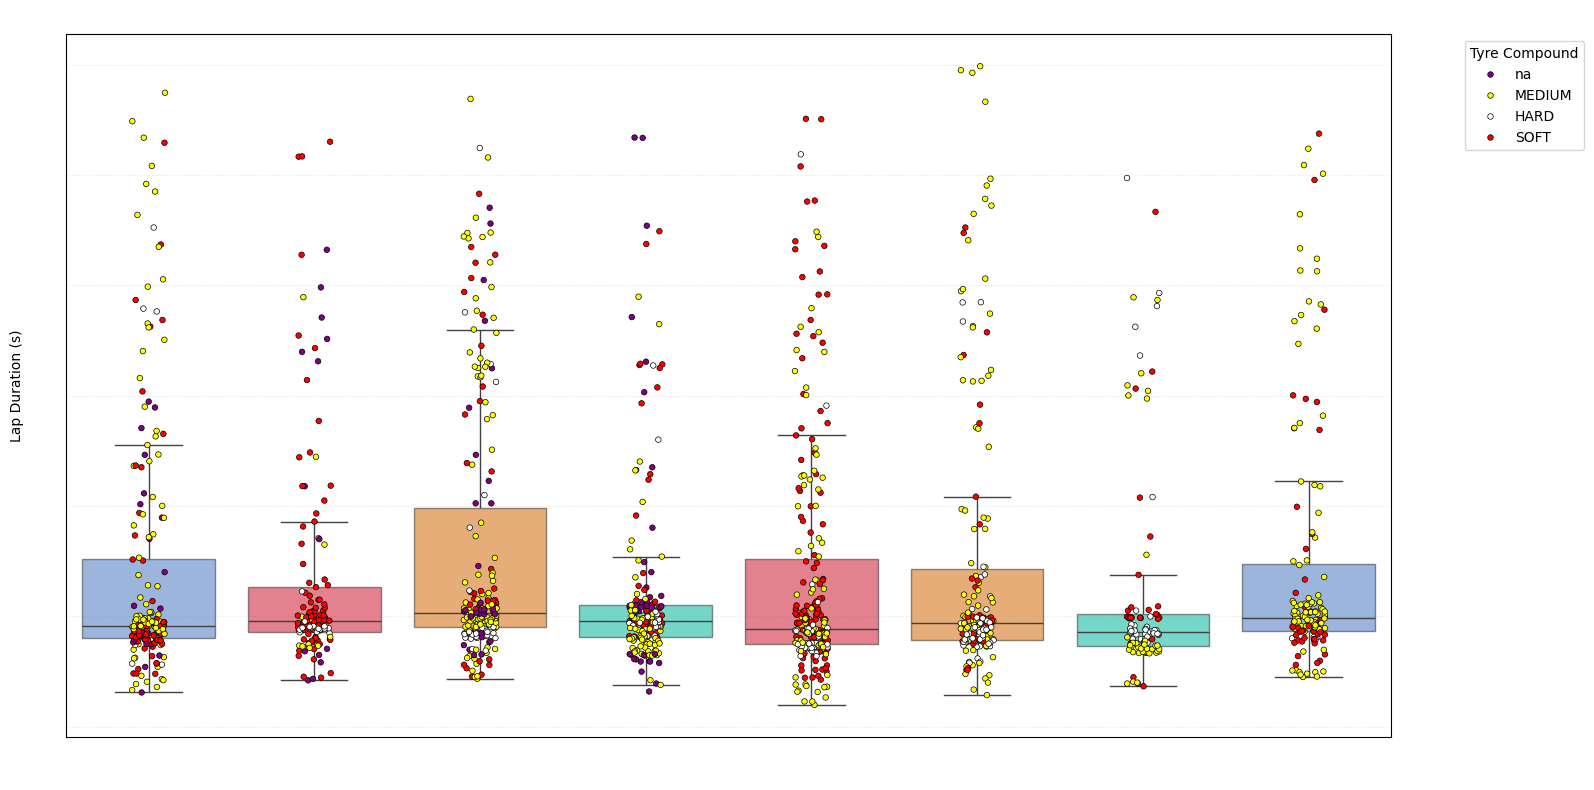

In [47]:
laps_graph = sqldf("SELECT * FROM laps WHERE name_acronym IN ('VER', 'HAD', 'NOR', 'PIA', 'HAM', 'LEC', 'RUS', 'ANT') AND lap_duration < 150")

compound_colors = {
    'SOFT': '#ff0000',
    'MEDIUM': '#ffff00',
    'HARD': '#ffffff',
    'INTERMEDIATE': '#00ff00', 
    'WET': '#0000ff',
    'na': '#800080'
}

plt.figure(figsize=(16, 8))

team_colors = laps_graph.groupby('name_acronym')['team_colour'].first().apply(lambda x: f"#{x}").to_dict()

sns.boxplot(
    data=laps_graph, 
    x='name_acronym', 
    y='lap_duration', 
    palette=team_colors,
    showfliers=False,
    boxprops=dict(alpha=0.6)
)

sns.stripplot(
    data=laps_graph,
    x='name_acronym',
    y='lap_duration',
    hue='compound',
    palette=compound_colors,
    jitter=True,
    size=4,
    marker='o',
    edgecolor='black',
    linewidth=0.5
)

plt.title('Lap Time Distribution by Driver with Tyre Compounds', color='white', fontsize=16)
plt.xlabel('Driver Name', color='white')
plt.ylabel('Lap Duration (s)', color='black')
plt.tick_params(colors='white')
plt.grid(axis='y', linestyle=':', alpha=0.3)

plt.legend(title='Tyre Compound', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()